# **Module  1: Data Collection and Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from IPython import display

In [2]:
data=sns.load_dataset('iris')
data.head(3)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [3]:
data.shape

(150, 5)

In [4]:
data.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

#Display Flower's

**Setosa**

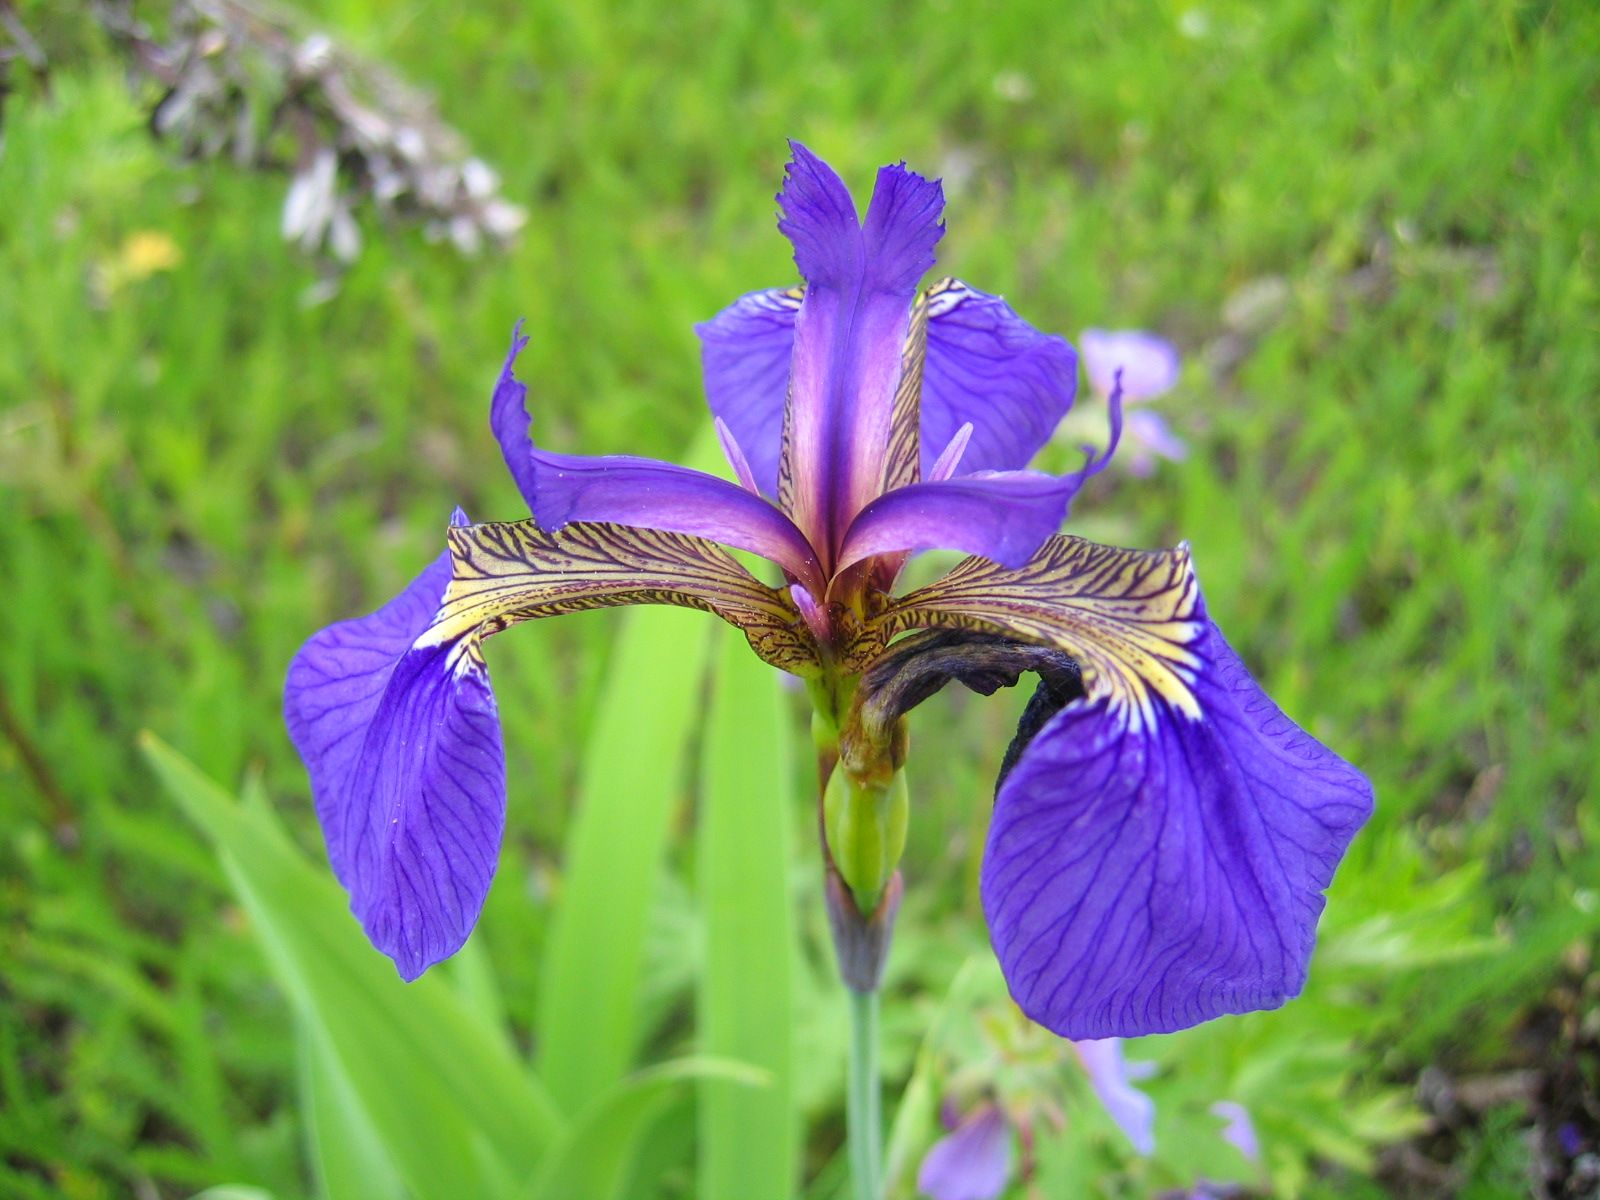

In [6]:
from IPython.display import Image
url = '/content/Irissetosa1.jpg'
Image(url,width=300, height=300)

**Versicolor**

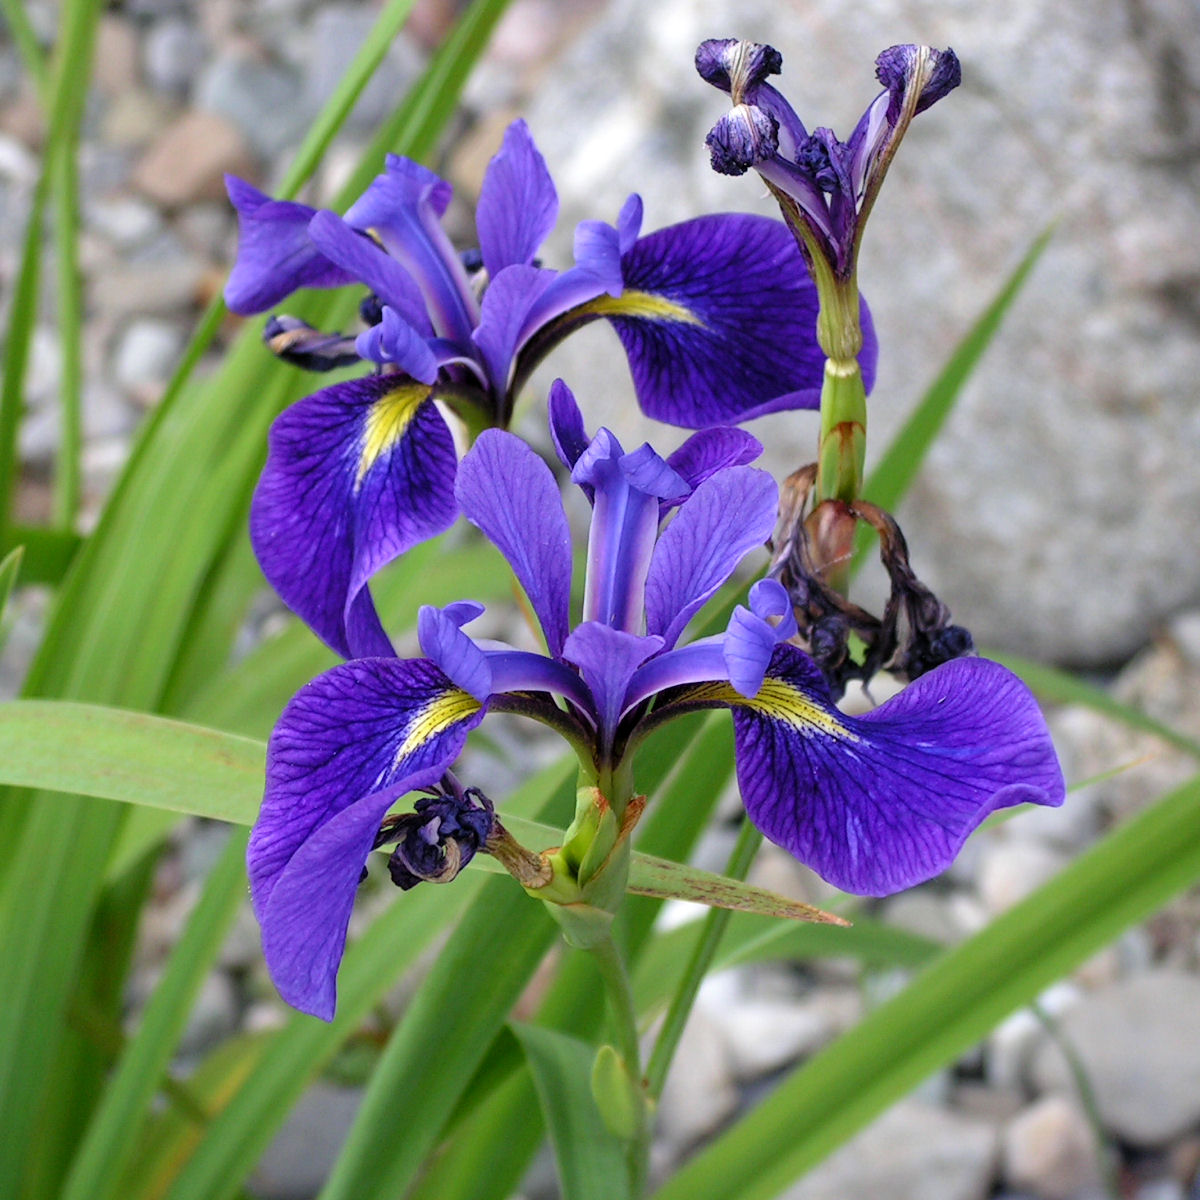

In [7]:
url = '/content/versicolor.jpg'
Image(url,width=300, height=300)

**Virginica**

In [8]:
url = '/content/Iris_virginica_2.jpg'
Image(url,width=300, height=300)

#Transfer Label to integer

In [9]:
data.species.replace({'setosa':0,'versicolor':1,'virginica':2}, inplace=True)

In [10]:
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


# Extracting Feature and Labels

In [29]:
x=data.drop('species',axis=1)
y=data['species']

In [12]:
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [13]:
y

,species
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


#Performing a train test split

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
x_train.shape

(120, 4)

# **Module 2: Logistic Regression Model Training**

Logistic regression is a method used when you want to predict categories instead of numbers. /it looks at the input features, combines them in a weighted way and then passes the result through a sigmoid function. The sigmoid squeezes the output into a value between 0 and 1, which you can think of as the probability of belonging to a certain class.

During training, the model adjusts its weights so that the predicted probabilities match the actual labels as closely as possible. When it’s time to make a prediction, it checks the probability. If the value is above a certain threshold, it assigns one class and if it’s below, it assigns the other. For multi-class problems, it uses the same idea but applies it to each class and picks the one with the highest probability.

**More Data Understanding**

Text(0, 0.5, 'count')

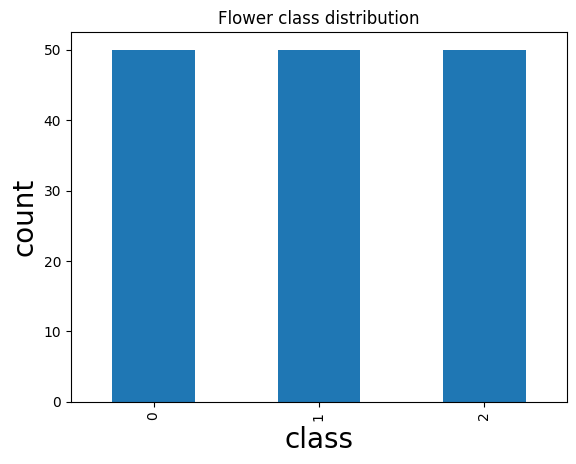

In [16]:
# iris flower dataset class distribution
nameplot = data['species'].value_counts().plot.bar(title='Flower class distribution')
nameplot.set_xlabel('class',size=20)
nameplot.set_ylabel('count',size=20)

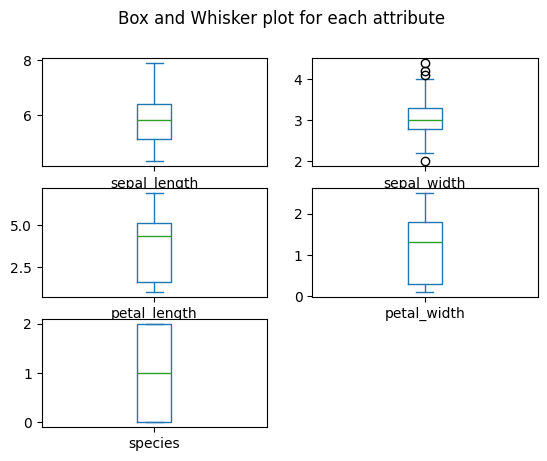

In [17]:
# box and whisker plots
data.plot(kind='box', subplots=True, layout=(3,2),
               sharex=False, sharey=False, title="Box and Whisker plot for each attribute")
plt.show()

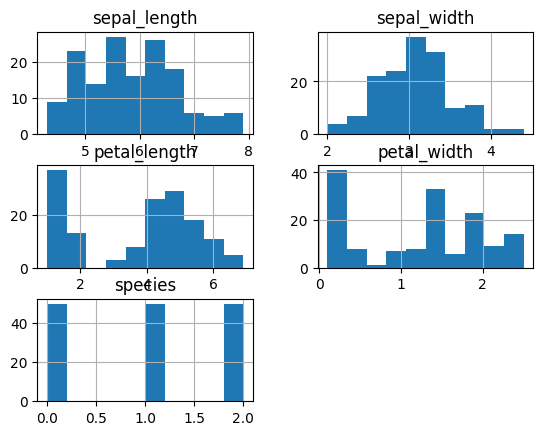

In [18]:
# plot histogram
data.hist()
plt.show()

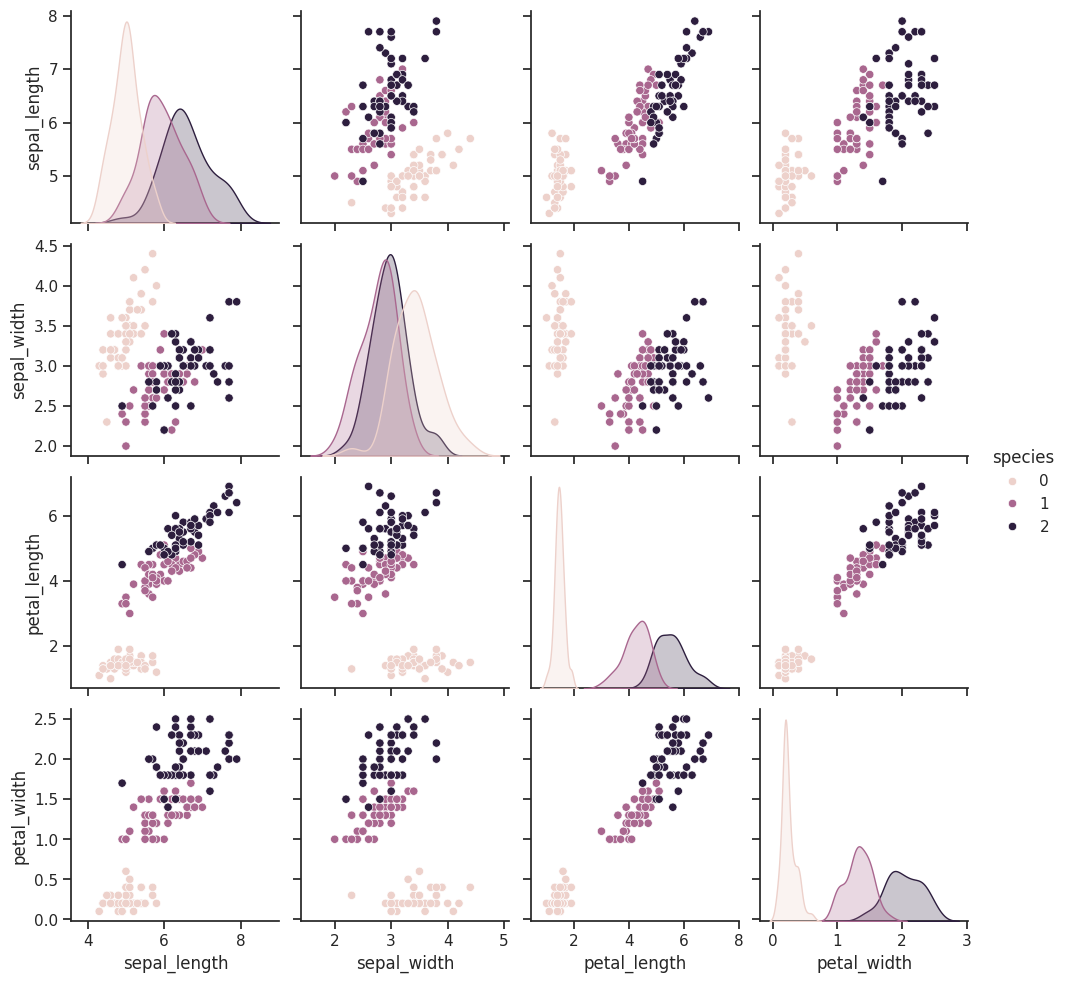

In [19]:
sns.set(style="ticks")
sns.pairplot(data, hue="species")

**Checking for train-test split shapes before taining**

In [20]:
print("X_train.shape:", x_train.shape)
print("X_test.shape:", x_test.shape)
print("Y_train.shape:", y_train.shape)
print("Y_test.shape:", y_test.shape)

X_train.shape: (120, 4)
X_test.shape: (30, 4)
Y_train.shape: (120,)
Y_test.shape: (30,)


**Model Building & Evaluation**

In [21]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [22]:
# defining model
model = LogisticRegression(solver='liblinear', multi_class="auto")

# cross validation settings
kfold = KFold(n_splits=10, random_state=7, shuffle=True)

# defining metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

# run cross validation
results = cross_validate(model, x_train, y_train, cv=kfold, scoring=scoring)

# print results
print("Logistic Regression Performance:")

print(f"Accuracy:  mean={results['test_accuracy'].mean():.4f}, std={results['test_accuracy'].std():.4f}")
print(f"Precision: mean={results['test_precision'].mean():.4f}, std={results['test_precision'].std():.4f}")
print(f"Recall:    mean={results['test_recall'].mean():.4f}, std={results['test_recall'].std():.4f}")
print(f"F1 score:  mean={results['test_f1'].mean():.4f}, std={results['test_f1'].std():.4f}")

Logistic Regression Performance:
Accuracy:  mean=0.9417, std=0.0750
Precision: mean=0.9480, std=0.0653
Recall:    mean=0.9519, std=0.0604
F1 score:  mean=0.9410, std=0.0747


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

**Loss Curves for Test & Train Datasets**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

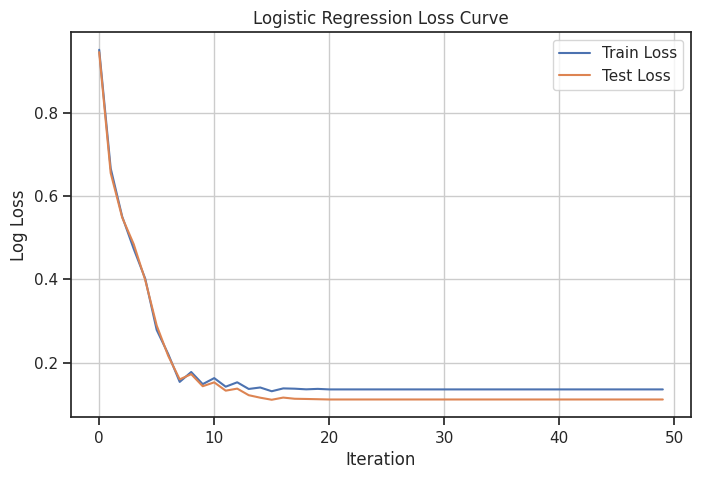

In [23]:
from sklearn.metrics import log_loss

# logistic regression with warm_start to record loss at each step
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1,
    warm_start=True
)

n_iters = 50  # number of points in the curve
train_losses = []
test_losses = []

for i in range(n_iters):
    # increase max_iter one step at a time
    model.max_iter += 1
    model.fit(x_train, y_train)

    # predictions for loss calculation
    y_train_prob = model.predict_proba(x_train)
    y_test_prob = model.predict_proba(x_test)

    # log loss
    train_losses.append(log_loss(y_train, y_train_prob))
    test_losses.append(log_loss(y_test, y_test_prob))

# plot
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Logistic Regression Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# Module 3  KNN Model Training

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# we already have: x_train, x_test, y_train, y_test

k_values = [3, 5, 7]
knn_results = []
confusion_matrices = {}

print("=== KNN Model Evaluation (k = 3, 5, 7) ===\n")

for k in k_values:
    # 1. Defining the model
    knn = KNeighborsClassifier(n_neighbors=k)

    # 2. Training the model
    knn.fit(x_train, y_train)

    # 3. Predictions on test set
    y_pred = knn.predict(x_test)

    # 4. Evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    # Saving results for comparison
    knn_results.append({
        "k": k,
        "accuracy": acc
    })
    confusion_matrices[k] = cm

    # 5. Printing detailed report
    print(f"----- KNN (k = {k}) -----")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=['setosa', 'versicolor', 'virginica']
    ))
    print("-" * 30 + "\n")

# Convert results to a DataFrame for easy viewing
knn_results_df = pd.DataFrame(knn_results)
display.display(knn_results_df)

=== KNN Model Evaluation (k = 3, 5, 7) ===

----- KNN (k = 3) -----
Accuracy: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

------------------------------

----- KNN (k = 5) -----
Accuracy: 1.0000
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.

,k,accuracy
0,3,1.000000
1,5,1.000000
2,7,0.966667


Best KNN model: k = 3 with accuracy = 1.0000


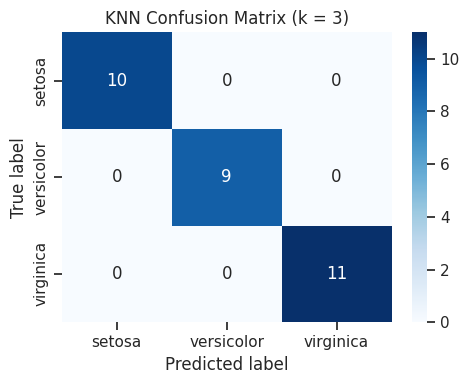

In [25]:
# Selecting Best KNN Model

best_row = knn_results_df.loc[knn_results_df['accuracy'].idxmax()]
best_k = int(best_row['k'])
best_accuracy = best_row['accuracy']

print(f"Best KNN model: k = {best_k} with accuracy = {best_accuracy:.4f}")

# Re-training best model on full training set
best_knn_model = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model.fit(x_train, y_train)

# Confusion matrix for best k
best_cm = confusion_matrices[best_k]

# Ploting confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['setosa', 'versicolor', 'virginica'],
    yticklabels=['setosa', 'versicolor', 'virginica']
)
plt.title(f"KNN Confusion Matrix (k = {best_k})")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


# **Module 4: Choosing Best model & Results and Models Explanation**

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import joblib

# 1. Comparing Model Performance
# Logistic Regression evaluation
lr_model = LogisticRegression(solver='liblinear')
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)
lr_acc = accuracy_score(y_test, lr_pred)
lr_cm = confusion_matrix(y_test, lr_pred)

# KNN evaluation (best_k already selected in Module 3)
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(x_train, y_train)
knn_pred = knn_model.predict(x_test)
knn_acc = accuracy_score(y_test, knn_pred)
knn_cm = confusion_matrix(y_test, knn_pred)


# Creating comparison table
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", f"KNN (k={best_k})"],
    "Accuracy": [lr_acc, knn_acc]
})

print("\n=== Model Performance Comparison ===")
print(comparison_df)

print("\nLogistic Regression Confusion Matrix:")
print(lr_cm)

print(f"\nKNN Confusion Matrix (k={best_k}):")
print(knn_cm)


=== Model Performance Comparison ===
                 Model  Accuracy
0  Logistic Regression       1.0
1            KNN (k=3)       1.0

Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

KNN Confusion Matrix (k=3):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


 **2. Select the Best Model**

In [27]:
if knn_acc > lr_acc:
    best_model_name = f"KNN (k={best_k})"
    final_model = knn_model
else:
    best_model_name = "Logistic Regression"
    final_model = lr_model

print(f"\nBest Model Selected: {best_model_name}")

# Manual test prediction
sample_input = [[5.1, 3.5, 1.4, 0.2]]   # Example
manual_pred = final_model.predict(sample_input)
print(f"\nManual Test Sample Prediction: {manual_pred[0]}")



Best Model Selected: Logistic Regression

Manual Test Sample Prediction: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


**Save best model**

In [28]:
joblib.dump(final_model, "best_model.pkl")
print("\nSaved best model as: best_model.pkl")


Saved best model as: best_model.pkl


## **3. Model Explanation**

Logistic Regression:
- Linear classification model.
- Strengths: Fast, simple, easy to interpret.
- Weaknesses: Works poorly if classes are not linearly separable.

KNN:
- Distance-based model using nearest neighbors.
- Strengths: Simple, performs well on small datasets.
- Weaknesses: Slow on large datasets, sensitive to feature scaling.

Why the Selected Model is Better:
- The chosen model achieved higher accuracy on the test set.
- This means it generalizes better and predicts unseen samples more accurately.

## **4. Results Summary (for README)**

Dataset Used:
- Iris dataset (150 samples, 3 classes, 4 numeric features)

Models Compared:
- Logistic Regression
- KNN (k = 3, 5, 7)

Model Performance:
- Logistic Regression Accuracy: 1.0000
- Best KNN Accuracy: 1.0000

Best Model:
- Logistic Regression

Key Insight:
- The best model generalizes better on unseen data.
- This model is used as the default classifier in the Iris prediction app.

